# Autoencoder with ACCESS-OM2

Autoencoder with ACCESS-OM2 Ocean Heat Content Data

This notebook trains an autoencoder on ocean heat content and surface heat flux data from the ACCESS-OM2 model using partial convolutions to handle land-masked regions.

In [1]:
# System and path handling
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
import xarray as xr

# PyEarthTools pipeline
import pyearthtools.data as petdata
from pyearthtools.data.transforms import TransformCollection
import pyearthtools.pipeline as petpipe
import pyearthtools.data.archive as arch

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Visualization
import matplotlib.pyplot as plt

# Configure device and random seed
torch.manual_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Source data and code directories
userbase = "/g/data/v46/txs156/"
repobase = "/home/156/txs156/uom/OM2-emulator/"

# Add the src directory to the Python path (relative to notebook location)
src_path = Path(repobase) / "src"
sys.path.insert(0, str(src_path))

# Import the ACCESS_OHC data accessor from om2_data_utils module
from om2_data_utils import ACCESS_OHC

# Import the PartialConv2d layer from om2_model_utils module
from om2_model_utils import PartialConv2d

In [2]:
normalisation_strategies = ["Global_in_time_and_space",
                            "Spatial_over_all_times",
                            "Spatial_per_month",
                            "Spatial_per_year"]


## Setup PyEarthTools data accessor and pipeline

In [3]:
# Keep one explicit time window so all normalisation paths are directly comparable.
normalisation_start = '2000-01'
normalisation_end = '2018-12'
normalisation_interval = '1 month'
normalisation_window = dict(start=normalisation_start, end=normalisation_end, interval=normalisation_interval)
normalised_variables = ["ocean_heat_content_2d", "total_surface_heat_flx"]

# Setup the data accessor and pipeline
ACCESS_OHC_accessor = ACCESS_OHC(
    ["area_t", "ocean_heat_content_2d", "total_surface_heat_flx"],
    root=userbase + "OM2-emulator/data/",
    surface_flux_mode="cumsum_energy",      # W/m² -> cumulative J/m²
    ohc_mode="anomaly_from_first",          # OHC(t) - OHC(t0)
    baseline_time=normalisation_start,
)

In [4]:
# -----------------------------------------------------------------------------
# Build normalisation stats explicitly from ocean-only values (land -> NaN),
# then use skipna reductions so land never contributes to mean/std.
# Must mirror accessor transforms exactly (same baseline_time, same units).
# -----------------------------------------------------------------------------
ds_stats = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
area_t = ds_stats["area_t"]

ds_stats = ds_stats.sel(time=slice(normalisation_start, normalisation_end))
ds_stats = ds_stats[normalised_variables].copy()


def _select_baseline_scalar(da, label):
    try:
        b = da.sel(time=label)
    except Exception:
        b = da.sel(time=label, method="nearest")

    # critical: remove time dimension/coord so subtraction broadcasts over all time
    if "time" in b.dims:
        b = b.isel(time=0, drop=True)
    return b

# OHC anomaly
ohc = ds_stats["ocean_heat_content_2d"].astype("float64")
ohc0 = _select_baseline_scalar(ohc, normalisation_start)
ds_stats["ocean_heat_content_2d"] = ohc - ohc0

# HF cumulative anomaly
qnet = ds_stats["total_surface_heat_flx"].astype("float64")
try:
    dt_seconds = qnet["time"].dt.days_in_month.astype("float64") * 86400.0
except Exception:
    dt_seconds = xr.DataArray(
        np.full(qnet.sizes["time"], 30 * 24 * 3600, dtype="float64"),
        coords={"time": qnet["time"]},
        dims=("time",),
    )

qnet_cumsum = (qnet * dt_seconds).cumsum(dim="time")
qnet0 = _select_baseline_scalar(qnet_cumsum, normalisation_start)
ds_stats["total_surface_heat_flx"] = qnet_cumsum - qnet0

# Keep mask derivation consistent with training/diagnostics convention:
# 1 = ocean, 0 = land.
mask_xr = xr.where(np.isnan(ds_stats.total_surface_heat_flx.isel(time=0)), 0, 1)
masked_stats = ds_stats.where(mask_xr == 1)

# Align spatial dimension names with the pipeline (Sort uses latitude/longitude).
rename_map = {}
if "yt_ocean" in masked_stats.dims:
    rename_map["yt_ocean"] = "latitude"
if "xt_ocean" in masked_stats.dims:
    rename_map["xt_ocean"] = "longitude"
if rename_map:
    masked_stats = masked_stats.rename(rename_map)

# 1) Global stats (scalar per variable)
global_mean_stats = masked_stats.mean(dim=("time", "latitude", "longitude"), skipna=True)
global_std_stats = masked_stats.std(dim=("time", "latitude", "longitude"), skipna=True)

# 2) Spatial stats (per-gridcell over all times)
spatial_mean_stats = masked_stats.mean(dim="time", skipna=True)
spatial_std_stats = masked_stats.std(dim="time", skipna=True)

# 3) Spatial climatology (month-wise per gridcell) then tile over all years.
spatial_monthly_mean_stats = masked_stats.groupby("time.month").mean(dim="time", skipna=True)
spatial_monthly_std_stats = masked_stats.groupby("time.month").std(dim="time", skipna=True)

# 4) Spatial annual (yearly per gridcell) then tile over all years.
spatial_annual_mean_stats = masked_stats.groupby("time.year").mean(dim="time", skipna=True)
spatial_annual_std_stats = masked_stats.groupby("time.year").std(dim="time", skipna=True)


month_indexer = xr.DataArray(
    masked_stats.time.dt.month.values,
    coords={"time": masked_stats.time.values},
    dims="time",
)

year_indexer = xr.DataArray(
    masked_stats.time.dt.year.values,
    coords={"time": masked_stats.time.values},
    dims="time",
)

spatial_monthly_mean_stats = spatial_monthly_mean_stats.sel(month=month_indexer).drop_vars("month", errors="ignore")
spatial_monthly_std_stats = spatial_monthly_std_stats.sel(month=month_indexer).drop_vars("month", errors="ignore")

spatial_annual_mean_stats = spatial_annual_mean_stats.sel(year=year_indexer).drop_vars("year", errors="ignore")
spatial_annual_std_stats = spatial_annual_std_stats.sel(year=year_indexer).drop_vars("year", errors="ignore")

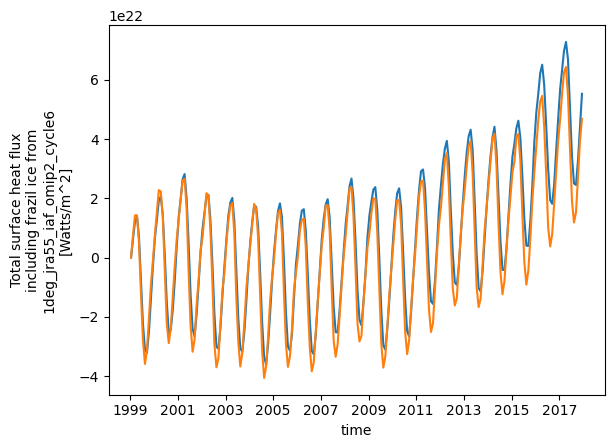

In [5]:
(ds_stats["ocean_heat_content_2d"]*area_t).sum(dim=["yt_ocean", "xt_ocean"]).plot()
(ds_stats["total_surface_heat_flx"]*area_t).sum(dim=["yt_ocean", "xt_ocean"]).plot()
# (spatial_monthly_mean_stats*area_t).sum(dim=["yt_ocean", "xt_ocean"]).plot()
# (spatial_annual_mean_stats*area_t).sum(dim=["yt_ocean", "xt_ocean"]).plot()

In [6]:
# Prevent divide-by-zero in fully masked/constant regions.
eps = 1e-6
global_std_stats = global_std_stats.where(global_std_stats > eps, eps)
spatial_std_stats = spatial_std_stats.where(spatial_std_stats > eps, eps)
spatial_monthly_std_stats = spatial_monthly_std_stats.where(spatial_monthly_std_stats > eps, eps)
spatial_annual_std_stats = spatial_annual_std_stats.where(spatial_annual_std_stats > eps, eps)

# Keep only model variables for consistency.
keep_vars = [v for v in normalised_variables if v in global_mean_stats.data_vars]
global_mean_stats = global_mean_stats[keep_vars]
global_std_stats = global_std_stats[keep_vars]
spatial_mean_stats = spatial_mean_stats[keep_vars]
spatial_std_stats = spatial_std_stats[keep_vars]
spatial_monthly_mean_stats = spatial_monthly_mean_stats[keep_vars]
spatial_monthly_std_stats = spatial_monthly_std_stats[keep_vars]
spatial_annual_mean_stats = spatial_annual_mean_stats[keep_vars]
spatial_annual_std_stats = spatial_annual_std_stats[keep_vars]

# Drop curvilinear geolocation coords from stats datasets so they match the
# pipeline structure after Drop(['geolat_t', 'geolon_t']) and avoid alignment
# side effects during xarray normalisation -> ToNumpy conversion.
for _ds_name in [
    "global_mean_stats",
    "global_std_stats",
    "spatial_mean_stats",
    "spatial_std_stats",
    "spatial_monthly_mean_stats",
    "spatial_monthly_std_stats",
    "spatial_annual_mean_stats",
    "spatial_annual_std_stats",
]:
    _ds = locals()[_ds_name]
    _drop_coords = [c for c in ["geolat_t", "geolon_t"] if c in _ds.coords or c in _ds.data_vars]
    if _drop_coords:
        _ds = _ds.drop_vars(_drop_coords, errors='ignore')
    locals()[_ds_name] = _ds

# Define pipeline normalisation operations for each strategy.
pipelines_normed = [
    petpipe.operations.xarray.normalisation.Evaluated(
        normalisation_eval="(sample - mean) / deviation",
        unnormalisation_eval="(sample * deviation) + mean",
        mean=global_mean_stats,
        deviation=global_std_stats,
    ),
    petpipe.operations.xarray.normalisation.Evaluated(
        normalisation_eval="(sample - mean) / deviation",
        unnormalisation_eval="(sample * deviation) + mean",
        mean=spatial_mean_stats,
        deviation=spatial_std_stats,
    ),
    petpipe.operations.xarray.normalisation.Evaluated(
        normalisation_eval="(sample - mean) / deviation",
        unnormalisation_eval="(sample * deviation) + mean",
        mean=spatial_monthly_mean_stats,
        deviation=spatial_monthly_std_stats,
    ),
        petpipe.operations.xarray.normalisation.Evaluated(
        normalisation_eval="(sample - mean) / deviation",
        unnormalisation_eval="(sample * deviation) + mean",
        mean=spatial_annual_mean_stats,
        deviation=spatial_annual_std_stats,
    ),
]


In [7]:
# Build one pipeline per normalisation strategy and retrieve one sample from each.
# This now uses full PET pipeline normalisation directly.
full_grid_over_time = []
pipelines = []
ipipe = []
n = []
sample_times = []
sample_skip_count = 10  # take the sample at index sample_skip_count consistently across modes

for i, norm_op in enumerate(pipelines_normed):
    print(i, normalisation_strategies[i])

    pipelines.append(petpipe.Pipeline(
        ACCESS_OHC_accessor,
        petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
        petdata.transforms.variables.Drop(['area_t']),
        petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),
        norm_op,
        petpipe.operations.xarray.values.FillNan(0),
        petpipe.operations.xarray.conversion.ToNumpy(),
        petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'),
        iterator=petpipe.iterators.DateRange(normalisation_start, normalisation_end, interval=normalisation_interval),
    ))

    full_grid_over_time.append(pipelines[i])
    ip_i = iter(pipelines[i])
    ipipe.append(ip_i)

    for _ in range(sample_skip_count):
        next(ip_i)
    sample_i = next(ip_i)

    n.append(sample_i)
    sample_time = masked_stats.time.isel(time=sample_skip_count).values if "time" in masked_stats.coords else np.datetime64(normalisation_start)
    sample_times.append(sample_time)
    print('sample shape:', sample_i.shape)
    print('sample time:', sample_time)


0 Global_in_time_and_space
sample shape: (1, 2, 300, 360)
sample time: 2000-11-14T00:00:00.000000000
1 Spatial_over_all_times
sample shape: (1, 2, 300, 360)
sample time: 2000-11-14T00:00:00.000000000
2 Spatial_per_month
sample shape: (1, 2, 300, 360)
sample time: 2000-11-14T00:00:00.000000000
3 Spatial_per_year
sample shape: (1, 2, 300, 360)
sample time: 2000-11-14T00:00:00.000000000


In [8]:
# Keep mask derivation from source data so land points stay excluded from metrics/loss.
ds_mask = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
mask_xr = xr.where(np.isnan(ds_mask.total_surface_heat_flx.isel(time=0)), 0, 1)
mask = mask_xr.values

## Do some checks - input data and partial convolutions

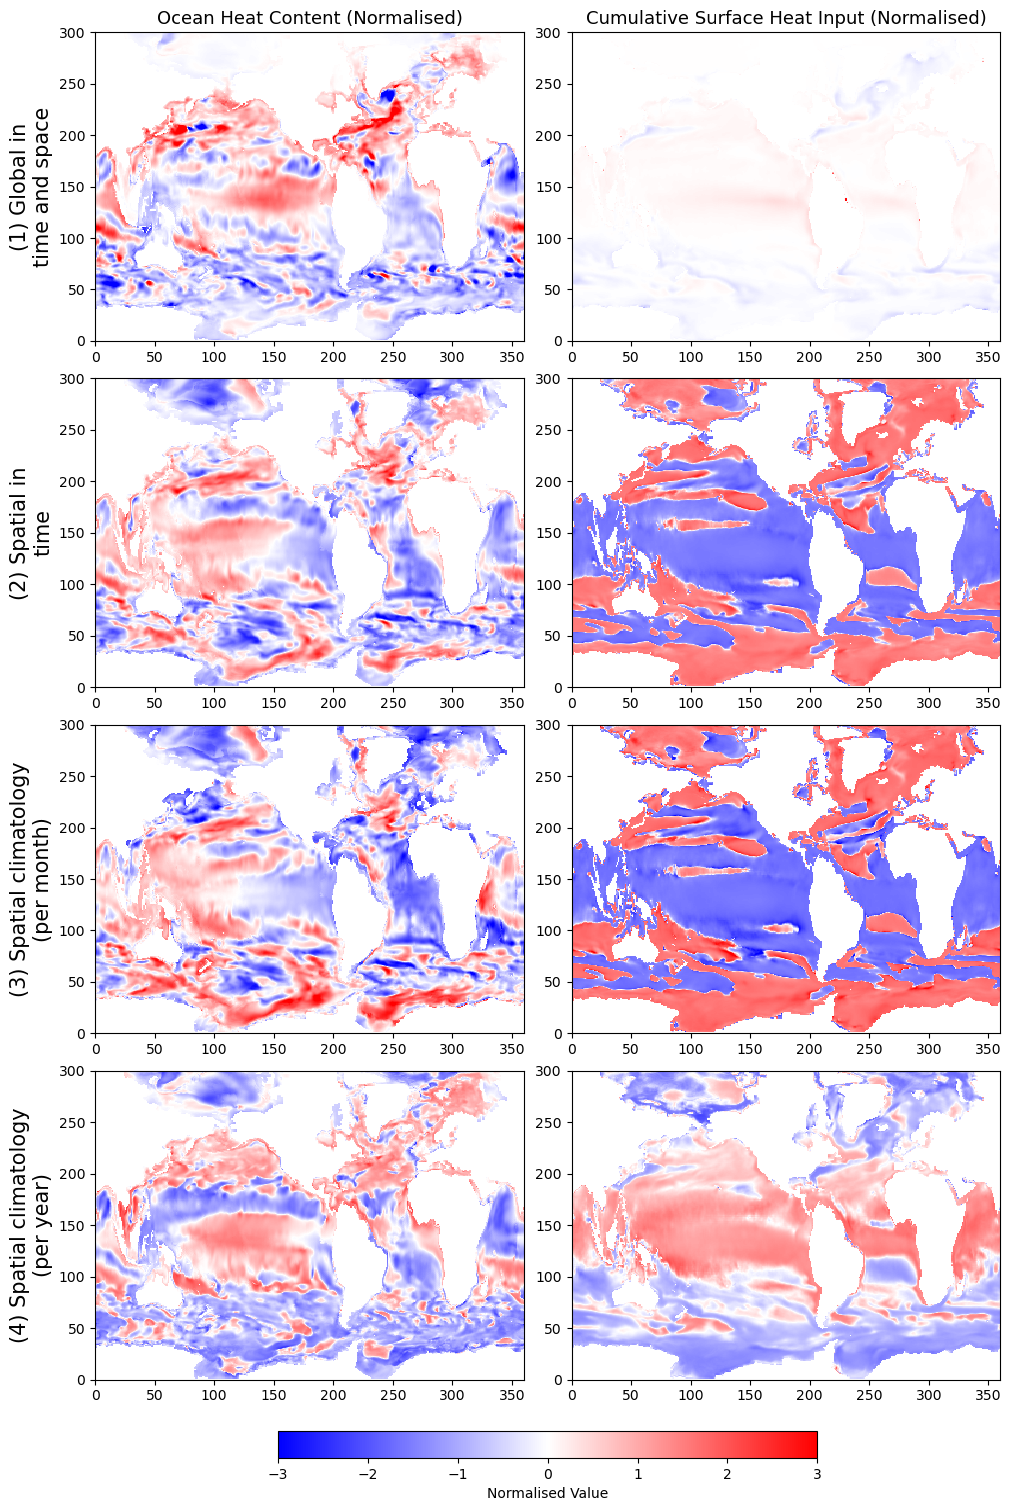

In [9]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 15), constrained_layout=True)
normalisation_clean = ["(1) Global in\ntime and space",
                       "(2) Spatial in\ntime",
                       "(3) Spatial climatology\n(per month)",
                       "(4) Spatial climatology\n(per year)"]
for i, norm_op in enumerate(pipelines_normed):
    OHC  = np.where(mask, n[i][0,0,:,:], np.nan)
    QNET = np.where(mask, n[i][0,1,:,:], np.nan)

    # Column 0: OHC
    pcm = axes[i, 0].pcolormesh(OHC, vmin=-3, vmax=3, cmap=plt.cm.bwr)
    
    # Column 1: QNET
    axes[i, 1].pcolormesh(QNET, vmin=-3, vmax=3, cmap=plt.cm.bwr)

    # Row labels = normalisation strategies
    axes[i, 0].set_ylabel(normalisation_clean[i], fontsize=15)

# ---- Column titles (top row only) ----
axes[0, 0].set_title("Ocean Heat Content (Normalised)", fontsize=13)
axes[0, 1].set_title("Cumulative Surface Heat Input (Normalised)", fontsize=13)

# ---- Single shared colorbar ----
cbar = fig.colorbar(pcm, ax=axes, orientation='horizontal', fraction=0.02, pad=0.02)
cbar.set_label("Normalised Value")
plt.savefig("/g/data/v46/txs156/OM2-emulator/figures/normlaisation_strategies.png", dpi=300, bbox_inches="tight")
plt.show()


Input shape: torch.Size([1, 1, 300, 360])
Input Mask shape: torch.Size([1, 1, 300, 360])
Output shape: torch.Size([1, 1, 150, 180])
New Mask shape: torch.Size([1, 1, 150, 180])
Original valid fraction: 0.6463796296296296
New valid fraction: 0.6898888945579529


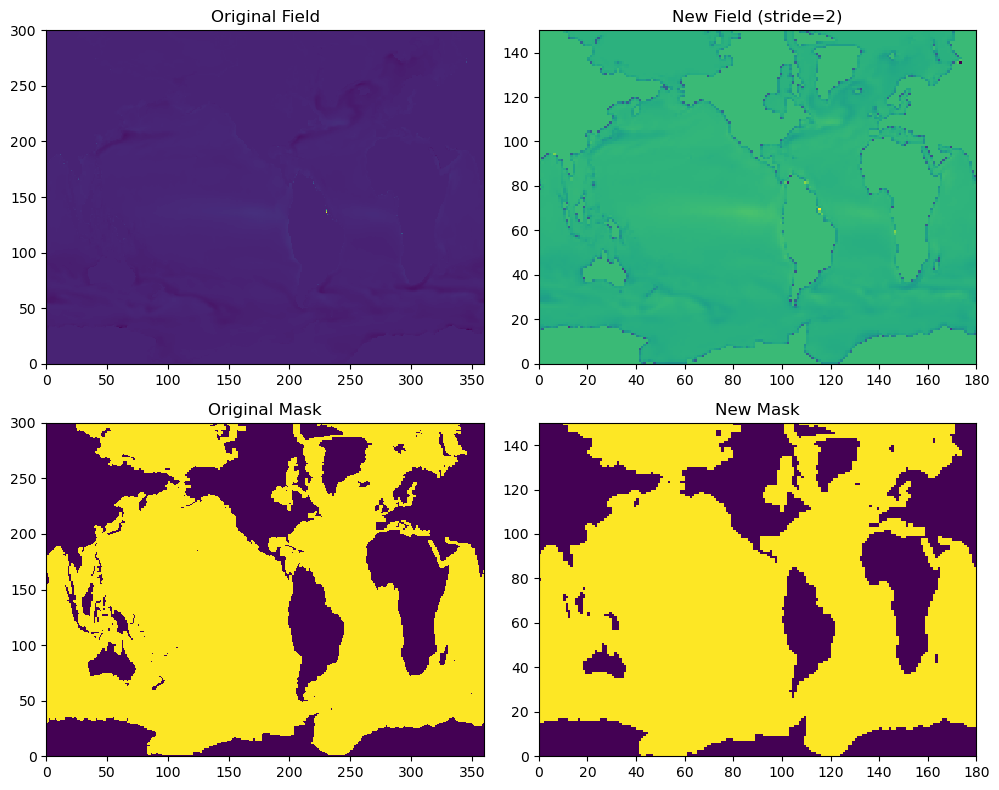

In [10]:
# Test Partial Convolution:
# convert to tensors
field = n[0][0,0,:,:]  # Take OHC (channel 0) for the first time step
x = torch.tensor(field, dtype=torch.float32)
mask_t = torch.tensor(mask, dtype=torch.float32)  # Explicit .values to extract numpy array
x = x.unsqueeze(0).unsqueeze(0)
mask_t = mask_t.unsqueeze(0).unsqueeze(0)

# Do an example convolution:
layer = PartialConv2d(in_ch=1,out_ch=1,kernel_size=3,stride=2,padding=1)
out, new_mask = layer(x, mask_t)

print("Input shape:", x.shape)
print("Input Mask shape:", mask_t.shape)
print("Output shape:", out.shape)
print("New Mask shape:", new_mask.shape)

# Convert tensors → numpy
new_field = out.detach().squeeze().numpy()
new_mask  = new_mask.detach().squeeze().numpy()

# Fractions covered by ocean:
print("Original valid fraction:", mask.mean().item())
print("New valid fraction:", new_mask.mean().item())

# Plot the results:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
im0 = axes[0,0].pcolormesh(field)
axes[0,0].set_title("Original Field")
im1 = axes[1,0].pcolormesh(mask)
axes[1,0].set_title("Original Mask")
im2 = axes[0,1].pcolormesh(new_field)
axes[0,1].set_title("New Field (stride=2)")
im3 = axes[1,1].pcolormesh(new_mask)
axes[1,1].set_title("New Mask")
plt.tight_layout()
plt.show()

## Define the model

In [11]:
class AutoEncoder(nn.Module):

    def __init__(self,
                 input_channel_count=2,
                 output_channel_count=2):

        super(AutoEncoder, self).__init__()

        # ---------- Encoder ----------
        self.enc1 = PartialConv2d(input_channel_count, 16, kernel_size=4, stride=2, padding=1)
        self.enc2 = PartialConv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(32, 64, kernel_size=7, stride=1, padding=3)

        # ---------- Decoder ----------
        self.dec1 = PartialConv2d(64, 32, kernel_size=7, stride=1, padding=3)
        self.dec2 = PartialConv2d(32, 16, kernel_size=3, stride=1, padding=1)
        self.dec3 = PartialConv2d(16, output_channel_count, kernel_size=4, stride=1, padding=2)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def encode(self, x, mask):
        """Encoder: returns latent representation and updated mask"""
        x, mask = self.enc1(x, mask)
        x = self.relu(x)
        x, mask = self.enc2(x, mask)
        x = self.relu(x)
        x, mask = self.enc3(x, mask)
        x = self.relu(x)
        return x, mask
    
    def decode(self, x, mask):
        """Decoder: takes latent representation and reconstructs output"""
        # upsample 1
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec1(x, mask)
        x = self.relu(x)

        # upsample 2
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec2(x, mask)
        x = self.relu(x)

        # final conv
        x, mask = self.dec3(x, mask)
        reconstructed = self.sigmoid(x)
        
        return reconstructed, mask
    
    def forward(self, x, mask):
        # Store input size for later
        input_h, input_w = x.shape[2], x.shape[3]

        # Encoder
        latent, latent_mask = self.encode(x, mask)

        # Decoder
        reconstructed, final_mask = self.decode(latent, latent_mask)
        
        # Crop to match input size (handles rounding errors from upsampling)
        reconstructed = reconstructed[:, :, :input_h, :input_w]

        # Enforce ocean-only output values so land cannot imprint on diagnostics.
        output_mask = mask[:, :, :input_h, :input_w]
        reconstructed = reconstructed * output_mask

        return reconstructed



## Initialize model and prepare data for training

In [12]:
# Initialize a lightweight model instance for quick smoke tests in the next cell.
# Full training models are created per normalisation mode in the training cell below.
model = AutoEncoder(input_channel_count=n[0].shape[1], output_channel_count=n[0].shape[1]).to(device)

# Keep criterion declaration for consistency with previous notebook workflow.
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

x = []

for i, norm_op in enumerate(pipelines_normed):
    # Convert numpy -> tensor for one reference sample used in normalisation diagnostics.
    x.append(torch.from_numpy(n[i]).float().to(device))

# Prepare mask with shape [1, 1, H, W] so it broadcasts over [T, C, H, W].
# We use ocean mask values so land points are excluded from normalisation/loss.
mask_t = torch.tensor(mask.astype(np.float32), dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

# Area weights for the global budget term. We zero land cells so the domain integral
# only includes ocean points and broadcasts cleanly over [T, C, H, W].
area_t_values = area_t.values if hasattr(area_t, "values") else area_t
area_t_t = torch.tensor(
    np.where(mask, area_t_values, 0.0),
    dtype=torch.float32,
).unsqueeze(0).unsqueeze(0).to(device)


Input shape: torch.Size([1, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([1, 2, 300, 360])


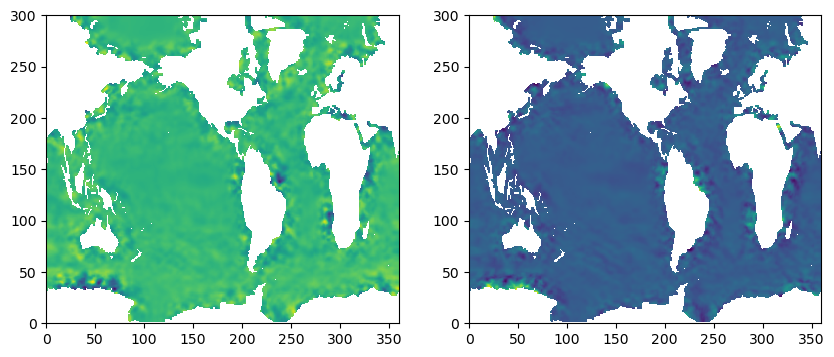

Input shape: torch.Size([1, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([1, 2, 300, 360])


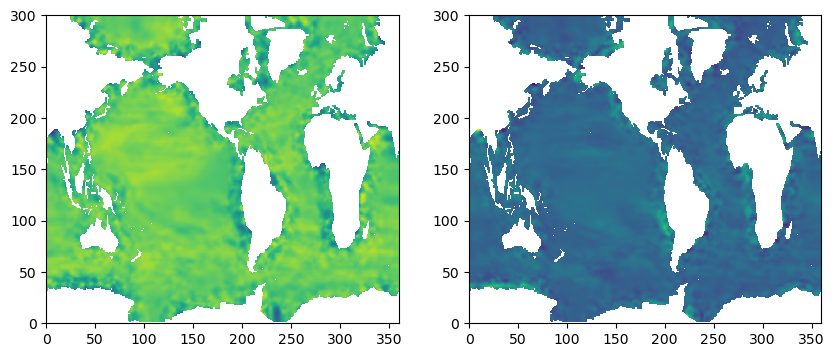

Input shape: torch.Size([1, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([1, 2, 300, 360])


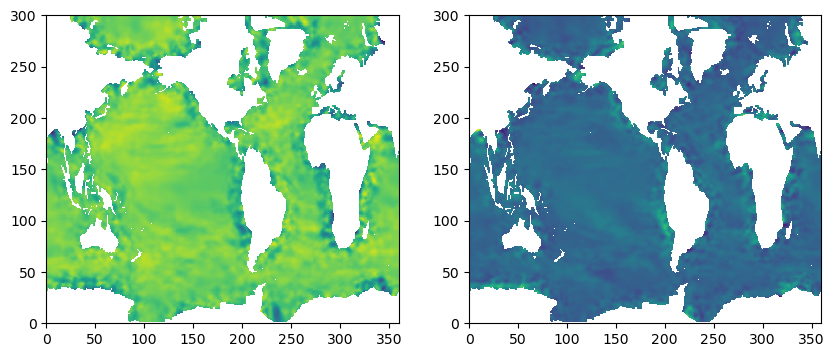

Input shape: torch.Size([1, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([1, 2, 300, 360])


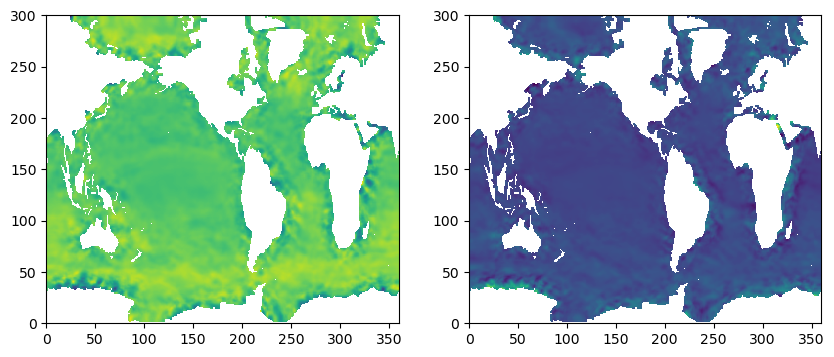

In [13]:
# Test model forward pass with untrained weights:
for i, norm_op in enumerate(pipelines_normed):

    prediction = model(x[i], mask_t)
    print("Input shape:", x[i].shape)
    print("Mask shape:", mask_t.shape)
    print("Prediction shape:", prediction.shape)
    
    image_numpy_for_display = prediction.to('cpu').detach().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Mask land in quick-look plots so visual checks focus on ocean behaviour.
    ch0 = np.where(mask, image_numpy_for_display[0][0], np.nan)
    ch1 = np.where(mask, image_numpy_for_display[0][1], np.nan)

    axes[0].pcolormesh(ch0)
    axes[1].pcolormesh(ch1)
    plt.show()


In [14]:
arr = x[0].to('cpu').detach().numpy()[0]  # (C,H,W)
for ch,name in [(0,"OHC"),(1,"QNET")]:
    ocean = np.where(mask, arr[ch], np.nan)
    print(name, "min/max over ocean:", np.nanmin(ocean), np.nanmax(ocean))


QNET min/max over ocean: -6.6400113 11.110818
OHC min/max over ocean: -1.015539 9.493269


## Training loop

In [15]:
%%time


def train(x_in, mask_t, area_t_t, debug=True, num_epochs=1, max_samples=10, print_per=20, lambda_budget=1):

    # Training loop
    avg_losses = []
    total_area = area_t_t.sum().clamp_min(1e-12)

    for epoch in range(num_epochs):
        total_loss = 0.0
        epoch_step_count = min(max_samples, x_in.shape[0])

        for epoch_samples in range(1, epoch_step_count + 1):
            if epoch_samples % print_per == 0:
                print(epoch_samples, flush=True)

            if debug:
                print(epoch_samples)
                print("Input")
                print(x_in)

            optimizer.zero_grad()

            # Forward pass
            y = model(x_in, mask_t)

            # 1) Per-cell reconstruction loss (current masked L1 objective).
            diff = torch.abs(y - x_in)
            cell_loss = (diff * mask_t).sum() / mask_t.sum().clamp_min(1e-12)

            # 2) Global integral closure term.
            # We compare area-weighted domain integrals channel-by-channel and timestep-by-timestep.
            pred_global = (y * area_t_t * mask_t).sum(dim=(-2, -1))
            obs_global = (x_in * area_t_t * mask_t).sum(dim=(-2, -1))
            budget_loss = ((pred_global - obs_global) ** 2).mean() / (total_area ** 2)

            # Combined objective.
            loss = cell_loss + lambda_budget * budget_loss

            if debug:
                print("prediction")
                print(y)
                print("cell_loss")
                print(cell_loss)
                print("budget_loss")
                print(budget_loss)
                print("loss")
                print(loss)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / epoch_step_count
        avg_losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}', flush=True)

    return avg_losses


for i, norm_op in enumerate(pipelines_normed):
    # print("###########", normalisation_strategies[i], "###############")
    train(x[i], mask_t, area_t_t, debug=False, num_epochs=100, max_samples=15 * 1000, print_per=500, lambda_budget=1.0)


Epoch [1/100], Average Loss: 1.5543
Epoch [2/100], Average Loss: 1.5499
Epoch [3/100], Average Loss: 1.5455
Epoch [4/100], Average Loss: 1.5403
Epoch [5/100], Average Loss: 1.5340
Epoch [6/100], Average Loss: 1.5260
Epoch [7/100], Average Loss: 1.5156
Epoch [8/100], Average Loss: 1.5024
Epoch [9/100], Average Loss: 1.4860
Epoch [10/100], Average Loss: 1.4662
Epoch [11/100], Average Loss: 1.4425
Epoch [12/100], Average Loss: 1.4143
Epoch [13/100], Average Loss: 1.3814
Epoch [14/100], Average Loss: 1.3433
Epoch [15/100], Average Loss: 1.2999
Epoch [16/100], Average Loss: 1.2515
Epoch [17/100], Average Loss: 1.1985
Epoch [18/100], Average Loss: 1.1419
Epoch [19/100], Average Loss: 1.0830
Epoch [20/100], Average Loss: 1.0235
Epoch [21/100], Average Loss: 0.9651
Epoch [22/100], Average Loss: 0.9097
Epoch [23/100], Average Loss: 0.8593
Epoch [24/100], Average Loss: 0.8153
Epoch [25/100], Average Loss: 0.7788
Epoch [26/100], Average Loss: 0.7503
Epoch [27/100], Average Loss: 0.7295
Epoch [28/

## Compute final prediction

In [16]:
prediction = model(x[i], mask_t)
pred_np = prediction.detach().cpu().numpy()

# Build physical-space predictions for all normalisation modes.
mean_stats_by_mode = [global_mean_stats, spatial_mean_stats, spatial_monthly_mean_stats, spatial_annual_mean_stats]
prediction_phys_ds = []

# Channel convention used by model tensors follows normalised_variables order.
CHANNEL_TO_VAR = {ch: var for ch, var in enumerate(normalised_variables)}
VAR_TO_CHANNEL = {v: k for k, v in CHANNEL_TO_VAR.items()}
DISPLAY_CHANNEL_VARS = list(normalised_variables)

def _resolve_spatial_layout(sample_h, sample_w):
    ref_var = normalised_variables[0]

    # Prefer spatial stats because global stats can be scalar (() dims).
    if ref_var in spatial_mean_stats.data_vars:
        dims = [d for d in spatial_mean_stats[ref_var].dims if d != "time"]
        if len(dims) >= 2:
            y_dim, x_dim = dims[-2], dims[-1]
            y_vals = spatial_mean_stats.coords[y_dim].values if y_dim in spatial_mean_stats.coords else np.arange(sample_h)
            x_vals = spatial_mean_stats.coords[x_dim].values if x_dim in spatial_mean_stats.coords else np.arange(sample_w)
            return y_dim, x_dim, y_vals, x_vals

    # Fallback: generic labelled dimensions.
    return "latitude", "longitude", np.arange(sample_h), np.arange(sample_w)

sample_h, sample_w = pred_np.shape[2], pred_np.shape[3]
y_dim, x_dim, y_vals, x_vals = _resolve_spatial_layout(sample_h, sample_w)
sample_time = sample_times[i] if len(sample_times) > i else (masked_stats.time.isel(time=sample_skip_count).values if "time" in masked_stats.coords else np.datetime64(normalisation_start))

def _stack_display_vars(ds_mode):
    arrs = []
    for v in DISPLAY_CHANNEL_VARS:
        da = ds_mode[v]
        if "time" in da.dims:
            da = da.isel(time=0, drop=True)
        arrs.append(np.asarray(da.values))
    return np.stack(arrs, axis=0)[np.newaxis, ...]

for mode_idx, norm_op in enumerate(pipelines_normed):
    pred_ds_mode = xr.Dataset(
        {
            CHANNEL_TO_VAR[ch]: (("time", y_dim, x_dim), pred_np[np.newaxis, 0, ch, :, :])
            for ch in sorted(CHANNEL_TO_VAR)
        },
        coords={
            "time": [sample_time],
            y_dim: y_vals,
            x_dim: x_vals,
        },
    )

    prediction_phys_ds.append(norm_op.undo(pred_ds_mode))


# Backward-compatible aliases
prediction_phys_ds_selected = prediction_phys_ds[i]
pred_ds = pred_ds_mode
pred_display = _stack_display_vars(prediction_phys_ds_selected)


In [17]:
# Build mode-wise diagnostics artefacts used by latent/RMSE/plot cells.
import numpy as np
import xarray as xr
import torch

NORMALISATION_MODES = list(normalisation_strategies)
selected_mode_for_detail = NORMALISATION_MODES[0]

mean_stats_by_mode = [global_mean_stats, spatial_mean_stats, spatial_monthly_mean_stats, spatial_annual_mean_stats]

# Channel convention used by model tensors follows normalised_variables order.
CHANNEL_TO_VAR = {ch: var for ch, var in enumerate(normalised_variables)}
VAR_TO_CHANNEL = {v: k for k, v in CHANNEL_TO_VAR.items()}
DISPLAY_CHANNEL_VARS = list(normalised_variables)

def _resolve_spatial_layout(sample_h, sample_w):
    ref_var = normalised_variables[0]

    # Prefer spatial stats because global stats can be scalar (() dims).
    if ref_var in spatial_mean_stats.data_vars:
        dims = [d for d in spatial_mean_stats[ref_var].dims if d != "time"]
        if len(dims) >= 2:
            y_dim, x_dim = dims[-2], dims[-1]
            y_vals = spatial_mean_stats.coords[y_dim].values if y_dim in spatial_mean_stats.coords else np.arange(sample_h)
            x_vals = spatial_mean_stats.coords[x_dim].values if x_dim in spatial_mean_stats.coords else np.arange(sample_w)
            return y_dim, x_dim, y_vals, x_vals

    # Fallback: generic labelled dimensions.
    return "latitude", "longitude", np.arange(sample_h), np.arange(sample_w)

def _tensor_to_dataset(sample_np, sample_time):
    sample_h, sample_w = sample_np.shape[2], sample_np.shape[3]
    y_dim, x_dim, y_vals, x_vals = _resolve_spatial_layout(sample_h, sample_w)

    # Keep a singleton time dimension so undo() can align with any time-dependent
    # normalisation stats (eg monthly/annual tiled climatologies).
    ds = xr.Dataset(
        {
            CHANNEL_TO_VAR[ch]: (("time", y_dim, x_dim), sample_np[np.newaxis, 0, ch, :, :])
            for ch in sorted(CHANNEL_TO_VAR)
        },
        coords={
            "time": [sample_time],
            y_dim: y_vals,
            x_dim: x_vals,
        },
    )
    return ds

def _stack_display_vars(ds_mode):
    arrs = []
    for v in DISPLAY_CHANNEL_VARS:
        da = ds_mode[v]

        # Reduce any residual time dimension to the one sample represented by x_mode.
        if "time" in da.dims:
            da = da.isel(time=0, drop=True)

        arrs.append(np.asarray(da.values))

    return np.stack(arrs, axis=0)[np.newaxis, ...]

results_by_mode = {}
prediction_display_by_mode = {}
input_display_by_mode = {}

_was_training = model.training
model.eval()
with torch.no_grad():
    for mode_idx, mode in enumerate(NORMALISATION_MODES):
        # Capture the input snapshot *before* any model call so "Actual" cannot drift
        # even if a layer were to mutate tensors in-place.
        x_mode = x[mode_idx]
        input_np = x_mode.detach().cpu().numpy().copy()
        x_mode_for_model = x_mode.clone()

        sample_time = sample_times[mode_idx] if len(sample_times) > mode_idx else (masked_stats.time.isel(time=sample_skip_count).values if "time" in masked_stats.coords else np.datetime64(normalisation_start))

        latent, _ = model.encode(x_mode_for_model, mask_t)
        prediction_mode = model(x_mode_for_model, mask_t)

        pred_np = prediction_mode.detach().cpu().numpy()

        pred_ds_mode = _tensor_to_dataset(pred_np, sample_time)
        input_ds_mode = _tensor_to_dataset(input_np, sample_time)

        pred_phys_ds_mode = pipelines_normed[mode_idx].undo(pred_ds_mode)
        input_phys_ds_mode = pipelines_normed[mode_idx].undo(input_ds_mode)

        pred_display = _stack_display_vars(pred_phys_ds_mode)
        input_display = _stack_display_vars(input_phys_ds_mode)

        prediction_display_by_mode[mode] = pred_display
        input_display_by_mode[mode] = input_display

        results_by_mode[mode] = {
            "latent": latent.detach().cpu().numpy()[0],  # (C_latent, H_latent, W_latent)
            "prediction": pred_display,
            "input": input_display,
        }

if _was_training:
    model.train()


In [18]:
# Compare per-mode "actual" only over ocean (sanity check).
# If masking/undo are consistent, these differences should be near zero over ocean.

ocean_mask = mask.astype(bool)
reference_mode = NORMALISATION_MODES[0]
reference_actual = input_display_by_mode[reference_mode]

print(f"Reference mode: {reference_mode}")

for mode in NORMALISATION_MODES:
    actual = input_display_by_mode[mode]
    print(f"\nMode: {mode}")

    for var_name in DISPLAY_CHANNEL_VARS:
        ch = VAR_TO_CHANNEL[var_name]
        diff = np.where(ocean_mask, actual[0, ch] - reference_actual[0, ch], np.nan)

        max_abs = float(np.nanmax(np.abs(diff)))
        mean_abs = float(np.nanmean(np.abs(diff)))
        rmse = float(np.sqrt(np.nanmean(diff**2)))

        print(
            f"  {var_name}: max|Δ|={max_abs:.6e}, mean|Δ|={mean_abs:.6e}, RMSE={rmse:.6e}"
        )



Reference mode: Global_in_time_and_space

Mode: Global_in_time_and_space
  ocean_heat_content_2d: max|Δ|=0.000000e+00, mean|Δ|=0.000000e+00, RMSE=0.000000e+00
  total_surface_heat_flx: max|Δ|=0.000000e+00, mean|Δ|=0.000000e+00, RMSE=0.000000e+00

Mode: Spatial_over_all_times
  ocean_heat_content_2d: max|Δ|=7.328751e+02, mean|Δ|=2.187845e+01, RMSE=3.411802e+01
  total_surface_heat_flx: max|Δ|=3.087628e+04, mean|Δ|=1.063407e+02, RMSE=2.465874e+02

Mode: Spatial_per_month
  ocean_heat_content_2d: max|Δ|=5.812734e+02, mean|Δ|=2.101218e+01, RMSE=3.279862e+01
  total_surface_heat_flx: max|Δ|=3.430056e+04, mean|Δ|=1.057415e+02, RMSE=2.344538e+02

Mode: Spatial_per_year
  ocean_heat_content_2d: max|Δ|=4.800488e+02, mean|Δ|=1.873909e+01, RMSE=2.984907e+01
  total_surface_heat_flx: max|Δ|=5.519036e+03, mean|Δ|=1.598263e+01, RMSE=3.544275e+01


## 
Diagnostics

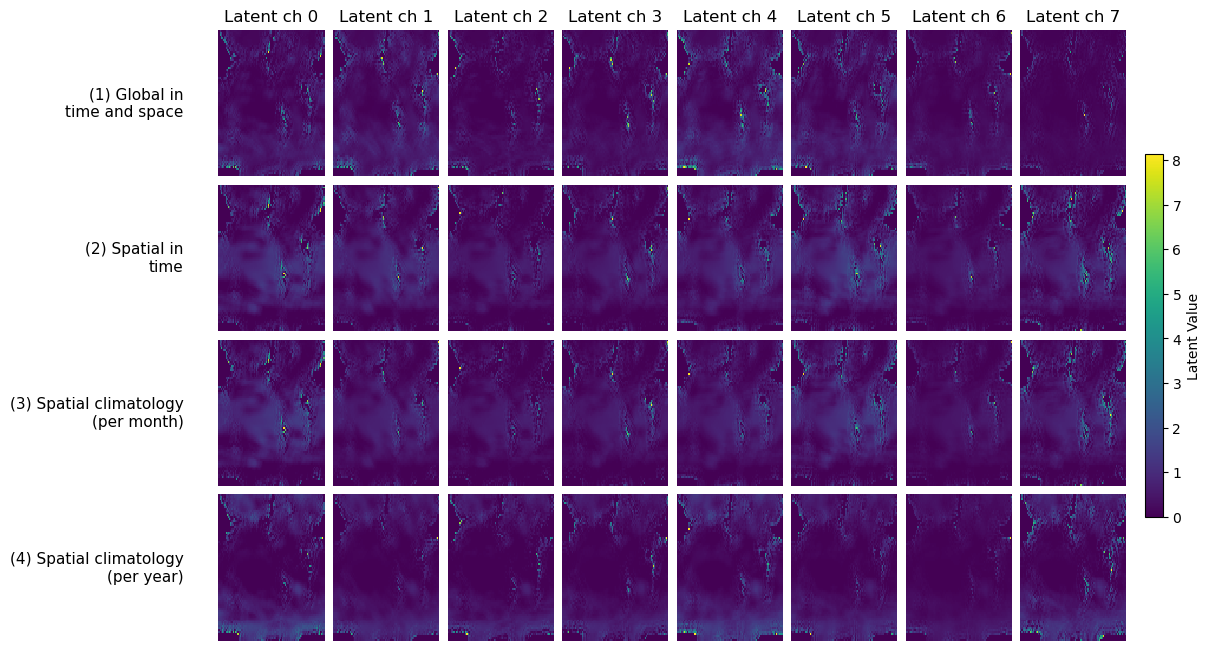

In [19]:
# ---- Clean labels ----
modes_to_plot = list(NORMALISATION_MODES)
labels_to_plot = list(normalisation_clean)

n_rows = len(modes_to_plot)
n_latent_show = min(8, min(results_by_mode[mode]["latent"].shape[0] for mode in modes_to_plot))

fig, axs = plt.subplots(
    n_rows, n_latent_show,
    figsize=(3 * n_latent_show*0.5, 3.2 * n_rows*0.5),
    constrained_layout=True
)

# Handle single-row edge case
if n_rows == 1:
    axs = np.expand_dims(axs, axis=0)

for row, (mode, label) in enumerate(zip(modes_to_plot, labels_to_plot)):
    z = results_by_mode[mode]["latent"]  # (C_latent, H, W)

    for col in range(n_latent_show):
        ax = axs[row, col]
        im = ax.pcolormesh(z[col], cmap="viridis")

        # ---- Clean look WITHOUT killing labels ----
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Column titles (top row only)
        if row == 0:
            ax.set_title(f"Latent ch {col}")

    # ---- Row labels (first column only) ----
    axs[row, 0].set_ylabel(
        label,
        fontsize=11,
        rotation=0,
        ha='right',
        va='center',
        labelpad=25
    )

# ---- Single shared colorbar ----
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("Latent Value")
plt.savefig("/g/data/v46/txs156/OM2-emulator/figures/latent_space.png", dpi=300, bbox_inches="tight")

plt.show()


In [20]:
## Compute RMSE (all normalisation modes)

# Shared area weights for fair spatially weighted RMSE across all modes.
ds = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
area_t = ds.area_t.values.astype(np.float64)
area_weighted = area_t * mask

RMSE_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]
    obs = input_display_by_mode[mode]

    # Channel convention in this notebook follows normalised_variables order.
    err_ohc = pred[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]] - obs[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]]
    err_sfx = pred[0, VAR_TO_CHANNEL["total_surface_heat_flx"]] - obs[0, VAR_TO_CHANNEL["total_surface_heat_flx"]]

    rmse_ohc = np.sqrt(np.nansum(err_ohc**2 * area_weighted) / np.nansum(area_weighted))
    rmse_sfx = np.sqrt(np.nansum(err_sfx**2 * area_weighted) / np.nansum(area_weighted))

    RMSE_by_mode[mode] = {
        "heat_flux": float(rmse_sfx),
        "ohc": float(rmse_ohc),
    }

    print(f"{mode} | RMSE heat_flux: {rmse_sfx:.6e}, RMSE OHC: {rmse_ohc:.6e}")

# Backward-compatible RMSE list for selected mode only.
RMSE = [
    RMSE_by_mode[selected_mode_for_detail]["heat_flux"],
    RMSE_by_mode[selected_mode_for_detail]["ohc"],
]


Global_in_time_and_space | RMSE heat_flux: 2.292023e+09, RMSE OHC: 1.048557e+09
Spatial_over_all_times | RMSE heat_flux: 9.212202e+09, RMSE OHC: 1.034985e+09
Spatial_per_month | RMSE heat_flux: 9.735627e+09, RMSE OHC: 9.568453e+08
Spatial_per_year | RMSE heat_flux: 4.142783e+08, RMSE OHC: 7.053721e+08


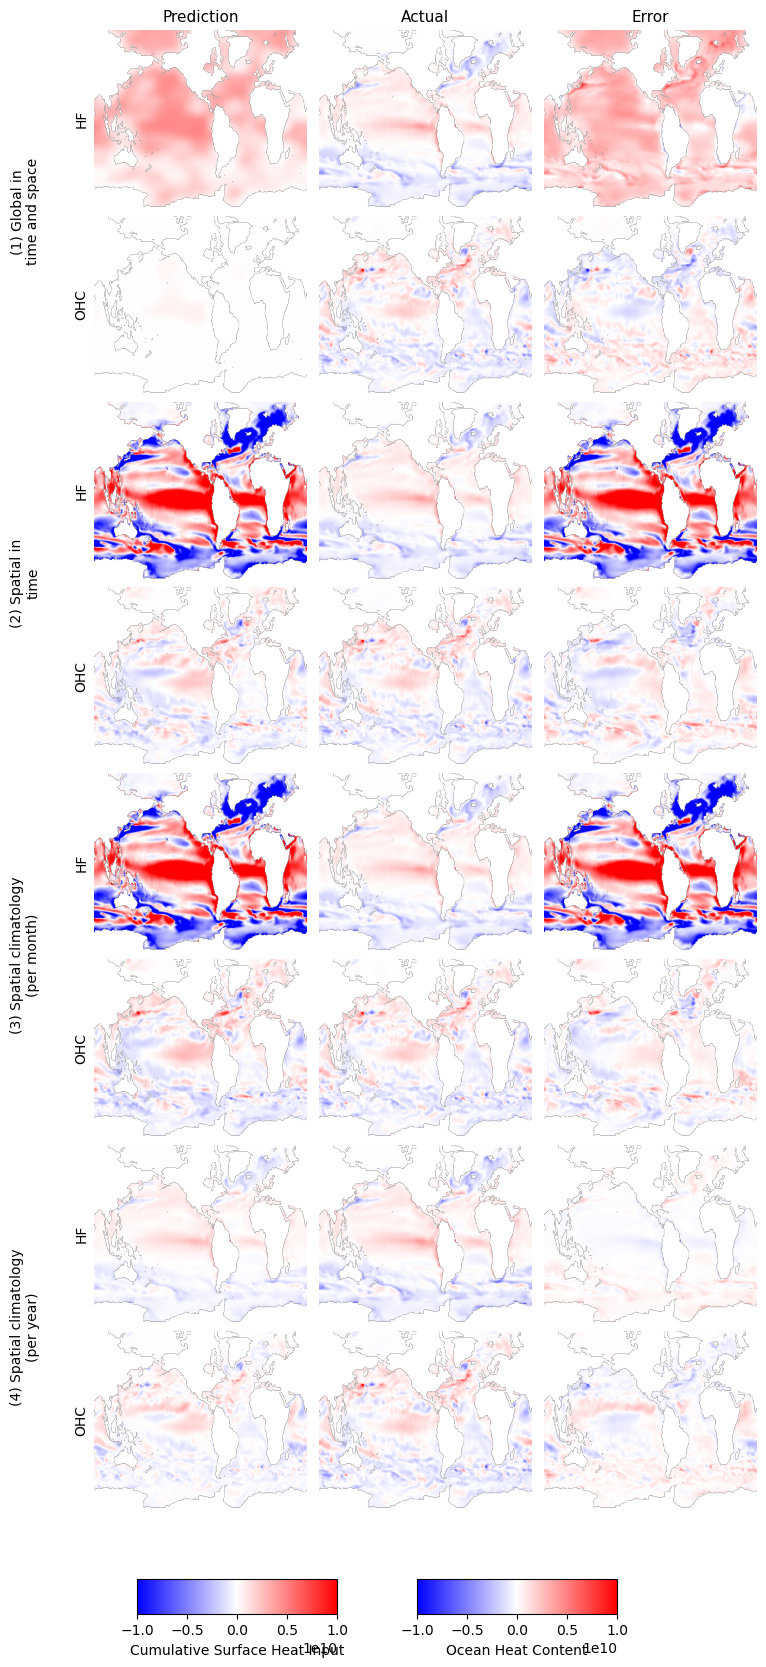

In [21]:
import numpy as np
import matplotlib.pyplot as plt

num_modes = len(NORMALISATION_MODES)

fig, axes = plt.subplots(
    nrows=2 * num_modes,
    ncols=3,
    figsize=(4*2, 2.2 * num_modes*2),
    gridspec_kw=dict(wspace=0.01, hspace=0.05)
)

if 2 * num_modes == 1:
    axes = np.expand_dims(axes, axis=0)

reference_mode = NORMALISATION_MODES[0]
obs_ref = input_display_by_mode[reference_mode]
ocean_mask = mask.astype(bool)

# Tight margins (this is key)
fig.subplots_adjust(left=0.14, right=0.98, top=0.96, bottom=0.12)

for mode_idx, mode in enumerate(NORMALISATION_MODES):
    pred = prediction_display_by_mode[mode]
    clean_label = normalisation_clean[mode_idx]

    # =========================
    # Heat Flux
    # =========================
    row_h = 2 * mode_idx

    pred_h = np.where(ocean_mask, pred[0, VAR_TO_CHANNEL["total_surface_heat_flx"]], np.nan)
    obs_h  = np.where(ocean_mask, obs_ref[0, VAR_TO_CHANNEL["total_surface_heat_flx"]], np.nan)
    err_h  = pred_h - obs_h

    im_h = axes[row_h, 0].imshow(pred_h, vmin=-1e10, vmax=1e10, cmap=plt.cm.bwr)
    axes[row_h, 1].imshow(obs_h,  vmin=-1e10, vmax=1e10, cmap=plt.cm.bwr)
    axes[row_h, 2].imshow(err_h,  vmin=-1e10, vmax=1e10, cmap=plt.cm.bwr)

    # =========================
    # OHC
    # =========================
    row_o = 2 * mode_idx + 1

    pred_o = np.where(ocean_mask, pred[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]], np.nan)
    obs_o  = np.where(ocean_mask, obs_ref[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]], np.nan)
    err_o  = pred_o - obs_o

    im_o = axes[row_o, 0].imshow(pred_o, vmin=-1e10, vmax=1e10, cmap=plt.cm.bwr)
    axes[row_o, 1].imshow(obs_o,  vmin=-1e10, vmax=1e10, cmap=plt.cm.bwr)
    axes[row_o, 2].imshow(err_o,  vmin=-1e10, vmax=1e10, cmap=plt.cm.bwr)

    # =========================
    # Clean styling
    # =========================
    for r in [row_h, row_o]:
        for c in range(3):
            ax = axes[r, c]
            ax.invert_yaxis()
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

    # Column titles once
    if mode_idx == 0:
        axes[row_h, 0].set_title("Prediction", fontsize=11)
        axes[row_h, 1].set_title("Actual", fontsize=11)
        axes[row_h, 2].set_title("Error", fontsize=11)

    # Variable labels
    axes[row_h, 0].set_ylabel("HF", fontsize=10)
    axes[row_o, 0].set_ylabel("OHC", fontsize=10)

    # Centered normalisation label (row pair)
    pos_h = axes[row_h, 0].get_position()
    pos_o = axes[row_o, 0].get_position()
    y_mid = 0.5 * (pos_h.y1 + pos_o.y0)

    fig.text(
        0.06,
        y_mid,
        clean_label,
        ha="center",
        va="center",
        rotation=90,
        fontsize=10
    )

# =========================
# Shared horizontal colorbars
# =========================

# HF colorbar
cax_h = fig.add_axes([0.2, 0.06, 0.25, 0.02])
cbar_h = fig.colorbar(im_h, cax=cax_h, orientation="horizontal")
cbar_h.set_label("Cumulative Surface Heat Input")

# OHC colorbar
cax_o = fig.add_axes([0.55, 0.06, 0.25, 0.02])
cbar_o = fig.colorbar(im_o, cax=cax_o, orientation="horizontal")
cbar_o.set_label("Ocean Heat Content")
plt.savefig("/g/data/v46/txs156/OM2-emulator/figures/Error_assessment.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
print(np.nansum(pred_h*area_t))
print(np.nansum(pred_o*area_t))
print(np.nansum(obs_h*area_t))
print(np.nansum(obs_o*area_t))


1.554749257537559e+22
1.1316415480791325e+22
-9.090583417806979e+21
-1.401214654431071e+22


In [23]:
# Compute integrated diagnostics for each normalisation mode with a shared
# canonical input field (mode-independent truth).

ocean_mask = mask.astype(bool)
area_weighted = np.where(ocean_mask, area_t, np.nan)

reference_mode = NORMALISATION_MODES[0]
obs_ref = input_display_by_mode[reference_mode]

integrated_series_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]

    integrated_series_by_mode[mode] = {
        "OHC_pred_J": np.nansum(pred[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]] * area_weighted, axis=1),
        "SFX_pred_J": np.nansum(pred[0, VAR_TO_CHANNEL["total_surface_heat_flx"]] * area_weighted, axis=1),
        "OHC_in_J": np.nansum(obs_ref[0, VAR_TO_CHANNEL["ocean_heat_content_2d"]] * area_weighted, axis=1),
        "SFX_in_J": np.nansum(obs_ref[0, VAR_TO_CHANNEL["total_surface_heat_flx"]] * area_weighted, axis=1),
    }

# Backward-compatible aliases.
OHC_pred_J = integrated_series_by_mode[selected_mode_for_detail]["OHC_pred_J"]
SFX_pred_J = integrated_series_by_mode[selected_mode_for_detail]["SFX_pred_J"]
OHC_in_J = integrated_series_by_mode[reference_mode]["OHC_in_J"]
SFX_in_J = integrated_series_by_mode[reference_mode]["SFX_in_J"]



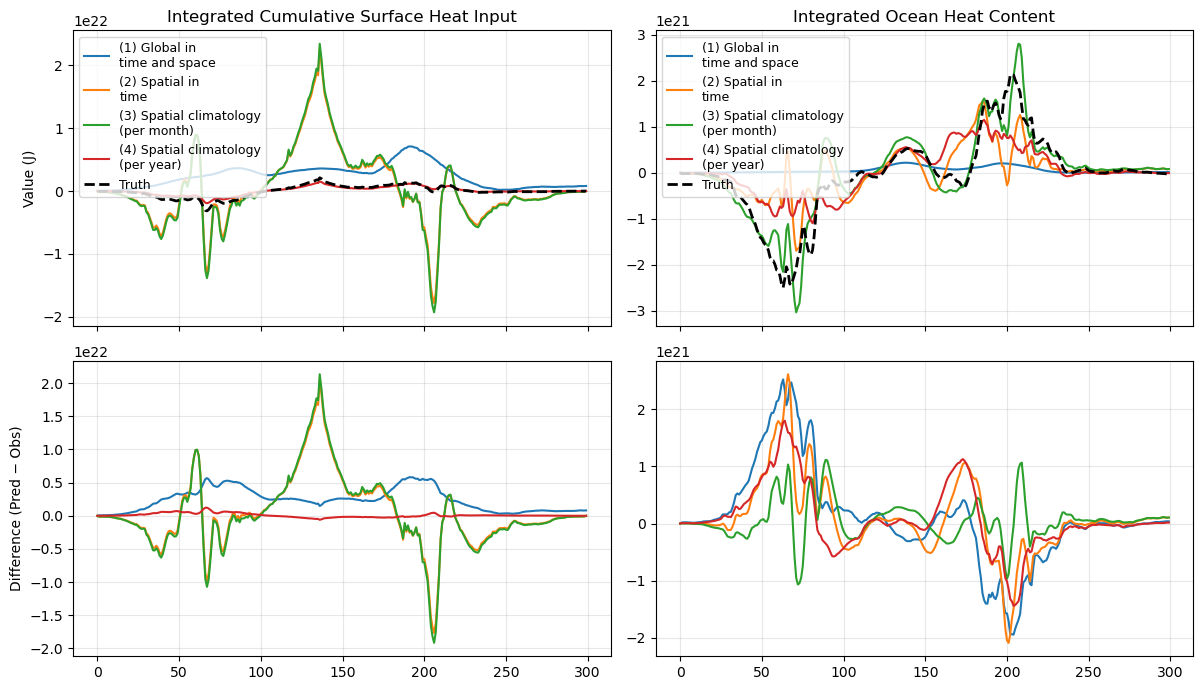

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

# Reference (observations)
reference_mode = NORMALISATION_MODES[0]
SFX_obs = integrated_series_by_mode[reference_mode]["SFX_in_J"]
OHC_obs = integrated_series_by_mode[reference_mode]["OHC_in_J"]

for i, mode in enumerate(NORMALISATION_MODES):
    label = normalisation_clean[i]

    SFX_pred = integrated_series_by_mode[mode]["SFX_pred_J"]
    OHC_pred = integrated_series_by_mode[mode]["OHC_pred_J"]

    # ---- Top row: timeseries ----
    axes[0, 0].plot(SFX_pred, label=label)
    axes[0, 1].plot(OHC_pred, label=label)

    # ---- Bottom row: differences ----
    axes[1, 0].plot(SFX_pred - SFX_obs, label=label)
    axes[1, 1].plot(OHC_pred - OHC_obs, label=label)

# ---- Observations (top row only) ----
axes[0, 0].plot(SFX_obs, "k--", linewidth=2, label="Truth")
axes[0, 1].plot(OHC_obs, "k--", linewidth=2, label="Truth")

# ---- Titles ----
axes[0, 0].set_title("Integrated Cumulative Surface Heat Input")
axes[0, 1].set_title("Integrated Ocean Heat Content")

# ---- Row labels ----
axes[0, 0].set_ylabel("Value (J)")
axes[1, 0].set_ylabel("Difference (Pred − Obs)")

# ---- Styling ----
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

# Legends (only once per column to avoid clutter)
axes[0, 0].legend(fontsize=9)
axes[0, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("/g/data/v46/txs156/OM2-emulator/figures/Flux_integral.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
ds0 = ACCESS_OHC_accessor.get(normalisation_start)
print(float(ds0["total_surface_heat_flx"].max(skipna=True)))
print(float(ds0["ocean_heat_content_2d"].max(skipna=True)))



2099305751498.4375
20791164928.0
